# Manifold Dynamics Verification

Goal: verify that the manifold (supply / exhaust, anode / cathode) is correctly modelled and calibrated.

The model equations live in [model/state_eq.py:`dxdt_Manifold`](../../model/state_eq.py) and the manifold-related coefficients in [model/coefficients.py](../../model/coefficients.py): `Vsm`, `Vem`, `Ksm_in`, `Ksm_out`, `Kem_in`, `Kem_out`, `C_D`, `A_T`, `Kp`, `Kd`, `tau_cp`, `tau_hum`, `n_cell`.

### Manifold ODEs (from `dxdt_Manifold`)

**Pressure** (ideal-gas mass balance, $\dot{m}=W_{in}-W_{out}$, $P = m R T / (V M)$):

$$\frac{dP_{asm}}{dt} = \frac{W_{asm,in} - n_{cell}\,W_{asm,out}}{V_{sm}\,M_{asm}}\,R\,T_{fc}$$
$$\frac{dP_{aem}}{dt} = \frac{n_{cell}\,W_{aem,in} - W_{aem,out}}{V_{em}\,M_{aem}}\,R\,T_{fc}$$
$$\frac{dP_{csm}}{dt} = \frac{W_{csm,in} - n_{cell}\,W_{csm,out}}{V_{sm}\,M_{csm}}\,R\,T_{fc}$$
$$\frac{dP_{cem}}{dt} = \frac{n_{cell}\,W_{cem,in} - W_{cem,out}}{V_{em}\,M_{cem}}\,R\,T_{fc}$$

**Humidity** (vapor mass balance, $\Phi = C_v / C_{v,sat} = C_v R T / P_{sat}$):

$$\frac{d\Phi_{asm}}{dt} = \frac{W_{v,asm,in} - J_{v,a,in}\,H_{gc}\,W_{gc}\,n_{cell}}{V_{sm}}\,\frac{R\,T_{fc}}{P_{sat}(T_{fc})}$$
$$\frac{d\Phi_{aem}}{dt} = \frac{J_{v,a,out}\,H_{gc}\,W_{gc}\,n_{cell} - W_{v,aem,out}}{V_{em}}\,\frac{R\,T_{fc}}{P_{sat}(T_{fc})}$$
$$\frac{d\Phi_{csm}}{dt} = \frac{W_{v,csm,in} - J_{v,c,in}\,H_{gc}\,W_{gc}\,n_{cell}}{V_{sm}}\,\frac{R\,T_{fc}}{P_{sat}(T_{fc})}$$
$$\frac{d\Phi_{cem}}{dt} = \frac{J_{v,c,out}\,H_{gc}\,W_{gc}\,n_{cell} - W_{v,cem,out}}{V_{em}}\,\frac{R\,T_{fc}}{P_{sat}(T_{fc})}$$

### Verification plan
1. Run a constant-load simulation long enough to reach steady state.
2. Check **pressure tracking**: $P_{asm}, P_{csm}$ should converge to the user setpoints `Pa_des`, `Pc_des`.
3. Check **humidity tracking**: $\Phi_{asm}, \Phi_{csm}$ should converge to `Phi_a_des`, `Phi_c_des`.
4. Check **mass balance** at steady state: $W_{asm,in} \approx n_{cell}\,W_{asm,out}$ (and the equivalents for aem, csm, cem).
5. Check **derivative consistency**: recompute $dP/dt$ and $d\Phi/dt$ from the analytical formula using the recovered fluxes and compare to a finite-difference derivative of the simulated trajectory.
6. Run a square-wave load and inspect dynamic response (overshoot, settling).

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

project_folder_name = "MFC2024"
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from model.dualscale import PEMFC
from model.coefficients import (R, n_cell, Vsm, Vem, Ksm_in, Ksm_out, Kem_in, Kem_out,
                                C_D, A_T, Kp, Kd, tau_cp, tau_hum, Psat, M_H2O, M_H2,
                                M_O2, M_N2, yO2_ext, Pext, Text, Phi_ext, gamma, gamma_H2,
                                C_v_sat)
from modules.signals import generate_constant_load, generate_step_load
from config.initialize import operating_inputs, parameters, init_x
from config.settings import solver_variable_names, solver_flux_names

print(f"Manifold geometry / orifice constants")
print(f"  n_cell  = {n_cell}")
print(f"  Vsm     = {Vsm:.2e} m^3")
print(f"  Vem     = {Vem:.2e} m^3")
print(f"  Ksm_in  = {Ksm_in:.2e}  kg/s/Pa")
print(f"  Ksm_out = {Ksm_out:.2e}  kg/s/Pa")
print(f"  Kem_in  = {Kem_in:.2e}  kg/s/Pa")
print(f"  Kem_out = {Kem_out:.2e}  kg/s/Pa")
print(f"  C_D     = {C_D}")
print(f"  A_T     = {A_T:.2e} m^2")
print(f"  Kp      = {Kp:.2e}    Kd = {Kd:.2e}")
print(f"  tau_cp  = {tau_cp} s    tau_hum = {tau_hum} s")

Manifold geometry / orifice constants
  n_cell  = 22
  Vsm     = 5.00e-05 m^3
  Vem     = 5.00e-05 m^3
  Ksm_in  = 2.00e-07  kg/s/Pa
  Ksm_out = 1.00e-07  kg/s/Pa
  Kem_in  = 2.00e-07  kg/s/Pa
  Kem_out = 1.00e-07  kg/s/Pa
  C_D     = 0.6
  A_T     = 1.26e-04 m^2
  Kp      = 1.00e-05    Kd = 1.00e-07
  tau_cp  = 1 s    tau_hum = 1 s


## 1. Steady-state test with a constant load
Hold the current density fixed and integrate long enough for all manifold states to settle.

In [2]:
i_const = 0.5e4  # A/m^2  (high enough to exercise the manifold, low enough for a stable cold start)
operating_inputs_const = dict(operating_inputs)
operating_inputs_const["current_density"] = generate_constant_load(i_const)

model_const = PEMFC(param=parameters,
                    operating_inputs=operating_inputs_const,
                    variable_names=solver_variable_names,
                    flux_names=solver_flux_names)
x0 = init_x(operating_inputs_const, parameters)
sol_const = solve_ivp(fun=model_const.dxdt, y0=x0, t_span=(0, 200),
                      method="BDF", max_step=0.1)
model_const._recovery(sol_const)
print("solver finished:", sol_const.success, "  n_pts =", len(sol_const.t))

solver finished: True   n_pts = 2069


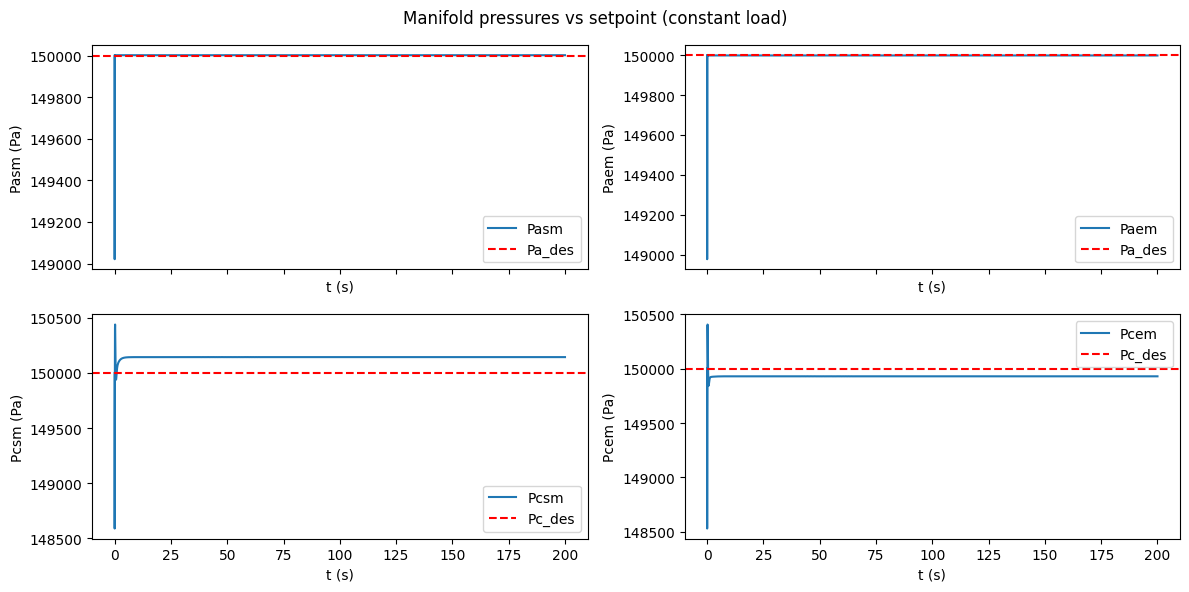

In [3]:
t = np.array(model_const.variables["t"])
Pa_des = operating_inputs_const["Pa_des"]
Pc_des = operating_inputs_const["Pc_des"]

fig, ax = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
ax[0,0].plot(t, model_const.variables["Pasm"], label="Pasm")
ax[0,0].axhline(Pa_des, color="r", linestyle="--", label="Pa_des")
ax[0,1].plot(t, model_const.variables["Paem"], label="Paem")
ax[0,1].axhline(Pa_des, color="r", linestyle="--", label="Pa_des")
ax[1,0].plot(t, model_const.variables["Pcsm"], label="Pcsm")
ax[1,0].axhline(Pc_des, color="r", linestyle="--", label="Pc_des")
ax[1,1].plot(t, model_const.variables["Pcem"], label="Pcem")
ax[1,1].axhline(Pc_des, color="r", linestyle="--", label="Pc_des")
for a, name in zip(ax.flatten(), ["Pasm", "Paem", "Pcsm", "Pcem"]):
    a.set_ylabel(f"{name} (Pa)")
    a.set_xlabel("t (s)")
    a.legend(loc="best")
fig.suptitle("Manifold pressures vs setpoint (constant load)")
fig.tight_layout()

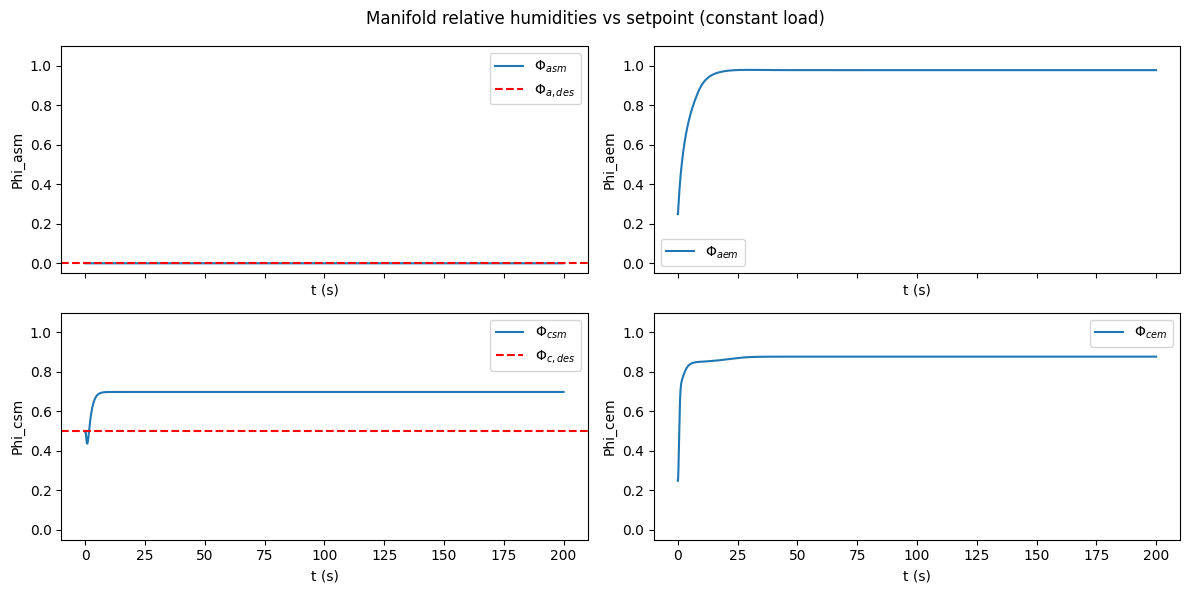

In [4]:
Phi_a_des = operating_inputs_const["Phi_a_des"]
Phi_c_des = operating_inputs_const["Phi_c_des"]

fig, ax = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
ax[0,0].plot(t, model_const.variables["Phi_asm"], label=r"$\Phi_{asm}$")
ax[0,0].axhline(Phi_a_des, color="r", linestyle="--", label=r"$\Phi_{a,des}$")
ax[0,1].plot(t, model_const.variables["Phi_aem"], label=r"$\Phi_{aem}$")
ax[1,0].plot(t, model_const.variables["Phi_csm"], label=r"$\Phi_{csm}$")
ax[1,0].axhline(Phi_c_des, color="r", linestyle="--", label=r"$\Phi_{c,des}$")
ax[1,1].plot(t, model_const.variables["Phi_cem"], label=r"$\Phi_{cem}$")
for a, name in zip(ax.flatten(), ["Phi_asm", "Phi_aem", "Phi_csm", "Phi_cem"]):
    a.set_ylabel(name)
    a.set_xlabel("t (s)")
    a.set_ylim(-0.05, 1.1)
    a.legend(loc="best")
fig.suptitle("Manifold relative humidities vs setpoint (constant load)")
fig.tight_layout()

## 2. Steady-state mass balance check

At steady state, each manifold ODE must vanish, which means

$$W_{asm,in} = n_{cell}\,W_{asm,out}, \quad W_{aem,out} = n_{cell}\,W_{aem,in}$$
$$W_{csm,in} = n_{cell}\,W_{csm,out}, \quad W_{cem,out} = n_{cell}\,W_{cem,in}$$

We use the last ~5 s of the simulation as a steady-state window and compare the two sides.

In [5]:
t_flux = np.array(model_const.variables["t"])  # fluxes are appended in step with variables["t"]
win = t_flux > (t_flux[-1] - 5.0)

def avg(name):
    return float(np.mean(np.array(model_const.fluxes[name])[win]))

checks = [
    ("Anode  supply : Wasm_in   vs n_cell * Wasm_out",
        avg("Wasm_in"),   n_cell * avg("Wasm_out")),
    ("Anode  exhaust: n_cell*Waem_in vs Waem_out",
        n_cell * avg("Waem_in"), avg("Waem_out")),
    ("Cathode supply : Wcsm_in   vs n_cell * Wcsm_out",
        avg("Wcsm_in"),   n_cell * avg("Wcsm_out")),
    ("Cathode exhaust: n_cell*Wcem_in vs Wcem_out",
        n_cell * avg("Wcem_in"), avg("Wcem_out")),
]
print(f"{'check':<55s}  {'lhs':>12s}  {'rhs':>12s}  {'rel.err':>10s}")
for label, lhs, rhs in checks:
    denom = max(abs(lhs), abs(rhs), 1e-30)
    rel = (lhs - rhs) / denom
    print(f"{label:<55s}  {lhs:12.3e}  {rhs:12.3e}  {rel:10.2%}")

check                                                             lhs           rhs     rel.err
Anode  supply : Wasm_in   vs n_cell * Wasm_out              4.241e-06     4.241e-06       0.00%
Anode  exhaust: n_cell*Waem_in vs Waem_out                  6.036e-06     6.036e-06      -0.00%
Cathode supply : Wcsm_in   vs n_cell * Wcsm_out             3.167e-04     3.167e-04       0.00%
Cathode exhaust: n_cell*Wcem_in vs Wcem_out                 3.080e-04     3.080e-04      -0.00%


## 3. Derivative consistency check

Re-evaluate the analytical $dP/dt$ and $d\Phi/dt$ formulas from `dxdt_Manifold` using the recovered fluxes and gas properties, and compare them to the finite-difference derivative of the simulated trajectory. If the implementation matches the equations, the two should overlap (up to integrator/finite-difference noise).

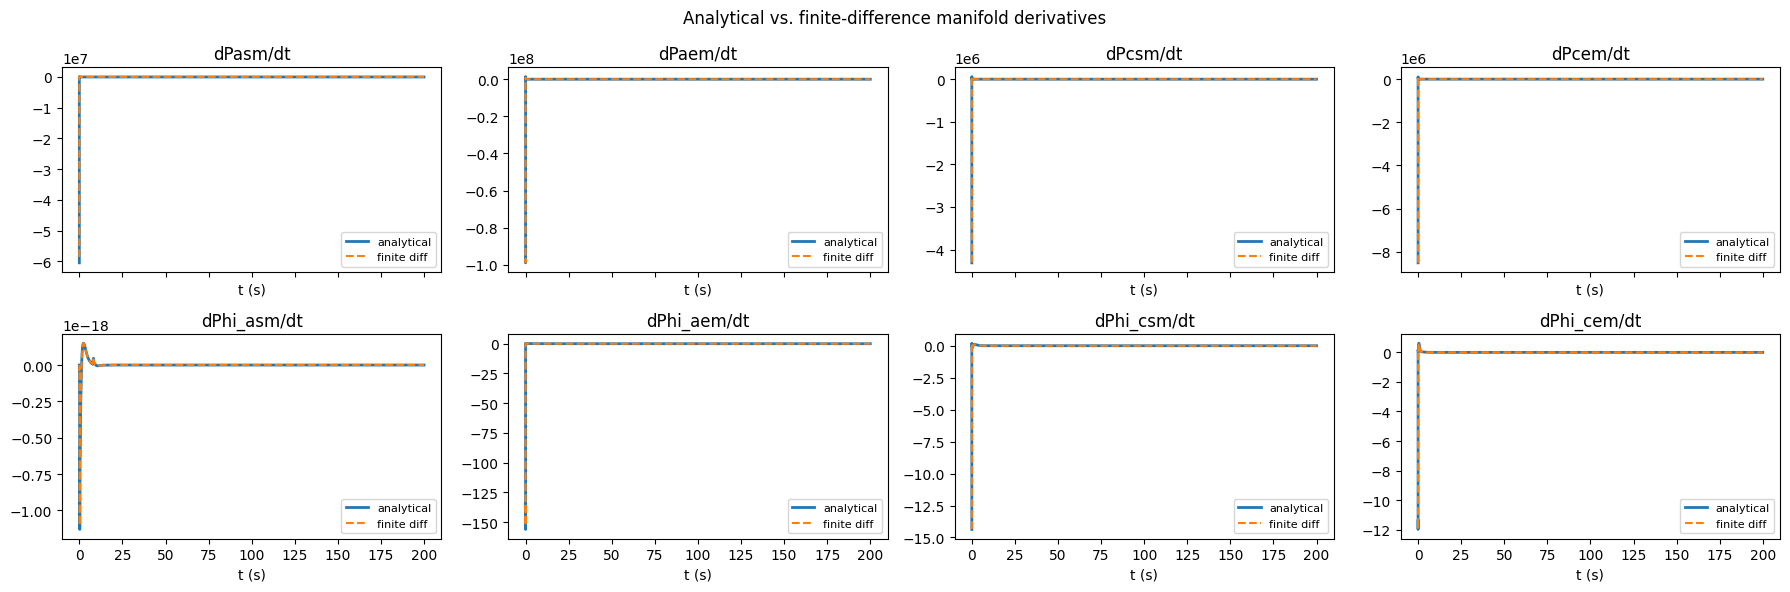

In [6]:
Tfc = operating_inputs_const["Tfc"]
Hgc = parameters["Hgc"]
Wgc = parameters["Wgc"]
Ps  = Psat(Tfc)

# Trajectories (same length as fluxes, recovered post-hoc by _recovery)
V = {k: np.array(model_const.variables[k]) for k in
     ["Pasm","Paem","Pcsm","Pcem","Phi_asm","Phi_aem","Phi_csm","Phi_cem"]}
F = {k: np.array(model_const.fluxes[k]) for k in
     ["Wasm_in","Wasm_out","Waem_in","Waem_out","Wcsm_in","Wcsm_out","Wcem_in","Wcem_out",
      "Wv_asm_in","Wv_aem_out","Wv_csm_in","Wv_cem_out",
      "Jv_a_in","Jv_a_out","Jv_c_in","Jv_c_out"]}

# Molar mass of each manifold (same expressions as in inst_values.py)
def molar_mass(side, side2, Phi, P):
    """side in {'a','c'} (gas), side2 in {'sm','em'} (manifold)."""
    xv = Phi * Ps / P
    if side == "a":
        return xv * M_H2O + (1 - xv) * M_H2
    return xv * M_H2O + yO2_ext * (1 - xv) * M_O2 + (1 - yO2_ext) * (1 - xv) * M_N2

Masm = molar_mass("a", "sm", V["Phi_asm"], V["Pasm"])
Maem = molar_mass("a", "em", V["Phi_aem"], V["Paem"])
Mcsm = molar_mass("c", "sm", V["Phi_csm"], V["Pcsm"])
Mcem = molar_mass("c", "em", V["Phi_cem"], V["Pcem"])

# Analytical derivatives (from dxdt_Manifold)
dPasm_an = (F["Wasm_in"]  - n_cell * F["Wasm_out"]) / (Vsm * Masm) * R * Tfc
dPaem_an = (n_cell * F["Waem_in"] - F["Waem_out"]) / (Vem * Maem) * R * Tfc
dPcsm_an = (F["Wcsm_in"]  - n_cell * F["Wcsm_out"]) / (Vsm * Mcsm) * R * Tfc
dPcem_an = (n_cell * F["Wcem_in"] - F["Wcem_out"]) / (Vem * Mcem) * R * Tfc

dPhi_asm_an = (F["Wv_asm_in"]  - F["Jv_a_in"]  * Hgc * Wgc * n_cell) / Vsm * R * Tfc / Ps
dPhi_aem_an = (F["Jv_a_out"] * Hgc * Wgc * n_cell - F["Wv_aem_out"]) / Vem * R * Tfc / Ps
dPhi_csm_an = (F["Wv_csm_in"]  - F["Jv_c_in"]  * Hgc * Wgc * n_cell) / Vsm * R * Tfc / Ps
dPhi_cem_an = (F["Jv_c_out"] * Hgc * Wgc * n_cell - F["Wv_cem_out"]) / Vem * R * Tfc / Ps

# Finite-difference derivatives of the recovered trajectories
def fd(y, x):
    return np.gradient(y, x)
dPasm_fd = fd(V["Pasm"], t);   dPaem_fd = fd(V["Paem"], t)
dPcsm_fd = fd(V["Pcsm"], t);   dPcem_fd = fd(V["Pcem"], t)
dPhi_asm_fd = fd(V["Phi_asm"], t); dPhi_aem_fd = fd(V["Phi_aem"], t)
dPhi_csm_fd = fd(V["Phi_csm"], t); dPhi_cem_fd = fd(V["Phi_cem"], t)

fig, ax = plt.subplots(2, 4, figsize=(18, 6), sharex=True)
pairs = [
    ("dPasm/dt",      dPasm_an,    dPasm_fd),
    ("dPaem/dt",      dPaem_an,    dPaem_fd),
    ("dPcsm/dt",      dPcsm_an,    dPcsm_fd),
    ("dPcem/dt",      dPcem_an,    dPcem_fd),
    ("dPhi_asm/dt",   dPhi_asm_an, dPhi_asm_fd),
    ("dPhi_aem/dt",   dPhi_aem_an, dPhi_aem_fd),
    ("dPhi_csm/dt",   dPhi_csm_an, dPhi_csm_fd),
    ("dPhi_cem/dt",   dPhi_cem_an, dPhi_cem_fd),
]
for a, (lbl, an, fdv) in zip(ax.flatten(), pairs):
    a.plot(t, an,  label="analytical", lw=2)
    a.plot(t, fdv, label="finite diff", ls="--")
    a.set_title(lbl)
    a.set_xlabel("t (s)")
    a.legend(loc="best", fontsize=8)
fig.suptitle("Analytical vs. finite-difference manifold derivatives")
fig.tight_layout()

## 4. Dynamic load response — parameter sensitivity

The steady-state checks confirm the manifold equations are correctly implemented. We now exercise the dynamic response under realistic load swings and see how each calibration parameter shapes that response.

**Load profiles** (square waves via `generate_step_load`):
- *Small step*: ≈ 0 → 10 A
- *Large step*: ≈ 0 → 35 A

For the cell active area `Aact = 31×10⁻⁴ m²`, these convert to peak current densities of ≈ 3.2×10³ A/m² and ≈ 1.1×10⁴ A/m². We use `i_low = 20 A/m²` (≈ 0.06 A, effectively zero) instead of a true zero to avoid model singularities. The intended 50 A target NaNs the BDF/Radau/LSODA solvers — that's a model stability boundary, not a solver issue — so the high-load case here is capped at 35 A.

**Parameter groups swept** (each group scaled together at 0.5×, 1×, 2× baseline, all other parameters held fixed):
- `Kp & Kd`            — PD throttle controller gains
- `Vsm & Vem`          — supply / exhaust manifold volumes
- `Ksm_out & Kem_in`   — manifold orifice coefficients
- `tau_cp & tau_hum`   — compressor / humidifier actuator first-order lags

**Metrics** (extracted on the rising-edge response of the last full square-wave period):
- *Peak deviation*    – max |P − P_des| after the edge
- *1 % settling time* – time from the edge until |P − P_des| stays below 0.01·P_des for the rest of the period
- *10 – 90 % rise time* – time for the disturbance magnitude to grow from 10 % to 90 % of its peak

In [7]:
import time
import pandas as pd
import model.coefficients as _cc
import model.inst_values as _iv
import model.state_eq as _se
import model.kinetic_eq as _ke

_PATCH_MODULES = [_cc, _iv, _se, _ke]
_TRACKED = ['Vsm', 'Vem', 'Ksm_in', 'Ksm_out', 'Kem_in', 'Kem_out',
            'Kp', 'Kd', 'tau_cp', 'tau_hum', 'C_D', 'A_T', 'n_cell']

# Capture baseline values once across re-runs of this cell
try:
    _BASELINE
except NameError:
    _BASELINE = {n: getattr(_cc, n) for n in _TRACKED if hasattr(_cc, n)}

def override(**kwargs):
    """Set parameter values across every module that imported them with `from ... import *`."""
    for name, value in kwargs.items():
        for mod in _PATCH_MODULES:
            if hasattr(mod, name):
                setattr(mod, name, value)

def restore():
    override(**_BASELINE)

def run_dyn(load, t_end=30.0, max_step=0.1, **param_overrides):
    """Run one PEMFC simulation under `load` with parameter overrides.
    Returns a dict with 'success' False (and NaN arrays) when the solver fails,
    so a single bad parameter combo doesn't abort the whole sweep."""
    restore()
    override(**param_overrides)
    try:
        op = dict(operating_inputs)
        op["current_density"] = load
        m = PEMFC(param=parameters, operating_inputs=op,
                  variable_names=solver_variable_names,
                  flux_names=solver_flux_names)
        x0 = init_x(op, parameters)
        try:
            sol = solve_ivp(fun=m.dxdt, y0=x0, t_span=(0, t_end),
                            method="BDF", max_step=max_step)
            m._recovery(sol)
            return {
                "t":       np.array(m.variables["t"]),
                "Pasm":    np.array(m.variables["Pasm"]),
                "Pcsm":    np.array(m.variables["Pcsm"]),
                "Phi_asm": np.array(m.variables["Phi_asm"]),
                "Phi_csm": np.array(m.variables["Phi_csm"]),
                "i_fc":    np.array(m.echem_traj["i_fc"]),
                "success": bool(sol.success),
            }
        except Exception as e:
            empty = np.array([])
            return {"t": empty, "Pasm": empty, "Pcsm": empty,
                    "Phi_asm": empty, "Phi_csm": empty, "i_fc": empty,
                    "success": False, "error": f"{type(e).__name__}: {e}"}
    finally:
        restore()

def find_rising_edge(t, i_fc, t_min):
    """Time of the next rising edge of i_fc after t_min (using a midpoint threshold)."""
    mask = t >= t_min
    tw = t[mask]; iw = i_fc[mask]
    if len(iw) < 2:
        return np.nan
    i_mid = 0.5 * (iw.min() + iw.max())
    above = iw > i_mid
    trans = np.where(np.diff(above.astype(int)) > 0)[0]
    return float(tw[trans[0]]) if len(trans) else np.nan

def step_metrics(t, P, P_des, t_edge, window):
    """Peak deviation, 1% settling time, 10-90% rise time within [t_edge, t_edge + window]."""
    out = {"peak_dev": np.nan, "settle_1pct": np.nan, "rise_10_90": np.nan}
    if not np.isfinite(t_edge) or len(t) == 0:
        return out
    mask = (t >= t_edge) & (t <= t_edge + window)
    tw = t[mask] - t_edge
    err = P[mask] - P_des
    abs_err = np.abs(err)
    if len(abs_err) == 0:
        return out
    ipk = int(np.argmax(abs_err))
    peak = float(abs_err[ipk])
    out["peak_dev"] = peak
    band = 0.01 * P_des
    if abs_err[-1] < band:
        idx = ipk
        while idx < len(abs_err) and not np.all(abs_err[idx:] < band):
            idx += 1
        if idx < len(tw):
            out["settle_1pct"] = float(tw[idx])
    before = abs_err[:ipk + 1]
    btw = tw[:ipk + 1]
    i10 = np.where(before > 0.1 * peak)[0]
    i90 = np.where(before > 0.9 * peak)[0]
    if len(i10) and len(i90):
        out["rise_10_90"] = float(btw[i90[0]] - btw[i10[0]])
    return out

print("Baseline parameter values captured:")
for k, v in _BASELINE.items():
    print(f"  {k:8s} = {v}")

Baseline parameter values captured:
  Vsm      = 5e-05
  Vem      = 5e-05
  Ksm_in   = 2e-07
  Ksm_out  = 1e-07
  Kem_in   = 2e-07
  Kem_out  = 1e-07
  Kp       = 1e-05
  Kd       = 1e-07
  tau_cp   = 1
  tau_hum  = 1
  C_D      = 0.6
  A_T      = 0.000126
  n_cell   = 22


In [8]:
Aact = parameters['Aact']
PERIOD = 6.0
T_END  = 30.0

I_HIGH_LO = 10.0  # A (small step)
I_HIGH_HI = 35.0  # A (large step — model unstable above ~35-40 A)
i_low_A_per_m2 = 20.0  # A/m^2 — small offset to avoid singularities

LOAD_PROFILES = {
    f"0 -> {int(I_HIGH_LO)} A": generate_step_load(
        tstart=0.0, tend=PERIOD,
        i_low=i_low_A_per_m2, i_high=I_HIGH_LO / Aact,
        tau_switch=1.0, t_switch=3.0),
    f"0 -> {int(I_HIGH_HI)} A": generate_step_load(
        tstart=0.0, tend=PERIOD,
        i_low=i_low_A_per_m2, i_high=I_HIGH_HI / Aact,
        tau_switch=1.0, t_switch=3.0),
}

for name in LOAD_PROFILES:
    i_h = I_HIGH_LO if "10" in name else I_HIGH_HI
    print(f"{name}: i_high = {i_h/Aact:.3e} A/m^2 (={i_h} A active)")

baseline_results = {name: run_dyn(load, t_end=T_END) for name, load in LOAD_PROFILES.items()}
for name, r in baseline_results.items():
    print(f"baseline {name}: success={r['success']} n_pts={len(r['t'])}")

0 -> 10 A: i_high = 3.226e+03 A/m^2 (=10.0 A active)
0 -> 35 A: i_high = 1.129e+04 A/m^2 (=35.0 A active)


d:\MFC2024\model\inst_values.py:266: RuntimeWarning: invalid value encountered in scalar power
  ans1 = (mliquid * Lgc * nu_l(Tfc)/ (Hgc * rho_H2O(Tfc) * nu_g)) ** (1/3)


baseline 0 -> 10 A: success=True n_pts=380
baseline 0 -> 35 A: success=True n_pts=416


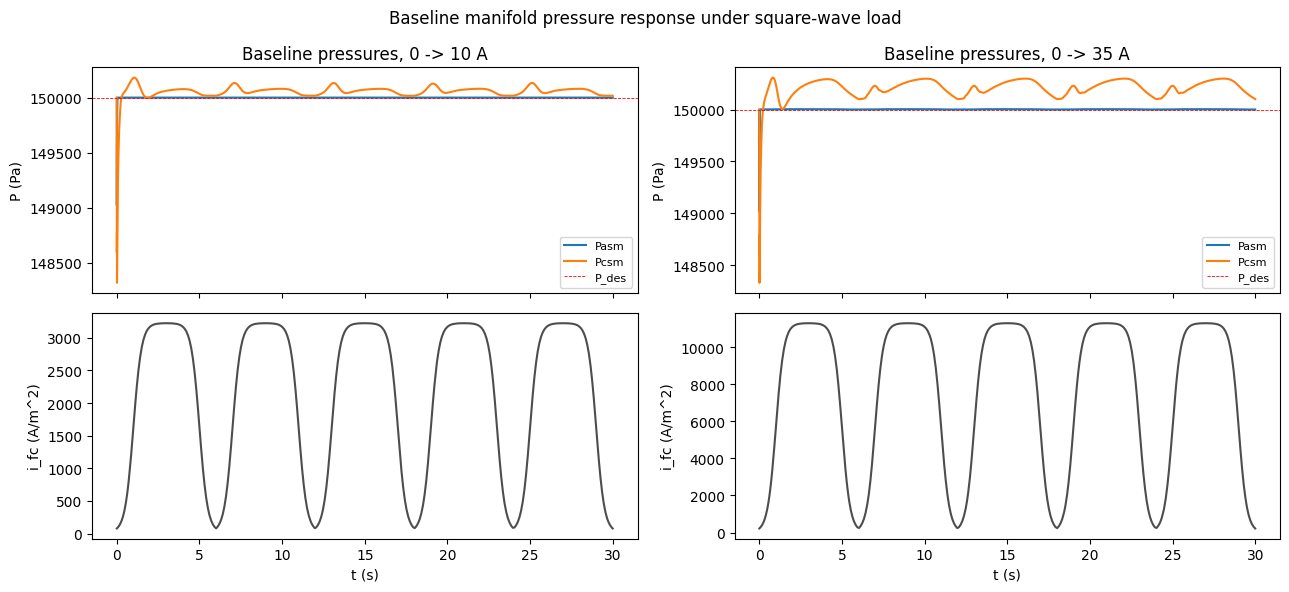

In [9]:
Pa_des = operating_inputs["Pa_des"]; Pc_des = operating_inputs["Pc_des"]
fig, ax = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
for c, (name, r) in enumerate(baseline_results.items()):
    aP = ax[0, c]
    aP.plot(r["t"], r["Pasm"], label="Pasm", color="#1f77b4")
    aP.plot(r["t"], r["Pcsm"], label="Pcsm", color="#ff7f0e")
    aP.axhline(Pa_des, color="r", ls="--", lw=0.6, label="P_des")
    aP.set_ylabel("P (Pa)")
    aP.set_title(f"Baseline pressures, {name}")
    aP.legend(fontsize=8, loc="best")
    aI = ax[1, c]
    aI.plot(r["t"], r["i_fc"], color="0.3")
    aI.set_xlabel("t (s)")
    aI.set_ylabel("i_fc (A/m^2)")
fig.suptitle("Baseline manifold pressure response under square-wave load")
fig.tight_layout()

### Parameter sweep — 4 groups × 3 levels × 2 loads = 24 runs

Each group is scaled together (`Kp` and `Kd` simultaneously, etc.) at 0.5×, 1×, 2× of its baseline value. All other parameters stay at baseline. Each parameter group is run against both the small (0 → 10 A) and large (0 → 50 A) load profiles.

In [10]:
SWEEP_FACTORS = [0.5, 1.0, 2.0]
SWEEP_GROUPS = {
    "Kp & Kd":          {"Kp":      _BASELINE["Kp"],      "Kd":      _BASELINE["Kd"]},
    "Vsm & Vem":        {"Vsm":     _BASELINE["Vsm"],     "Vem":     _BASELINE["Vem"]},
    "Ksm_out & Kem_in": {"Ksm_out": _BASELINE["Ksm_out"], "Kem_in":  _BASELINE["Kem_in"]},
    "tau_cp & tau_hum": {"tau_cp":  _BASELINE["tau_cp"],  "tau_hum": _BASELINE["tau_hum"]},
}

sweep_results = {}
t_start = time.time()
for gname, gbase in SWEEP_GROUPS.items():
    for f in SWEEP_FACTORS:
        overrides = {k: v * f for k, v in gbase.items()}
        for load_name, load in LOAD_PROFILES.items():
            key = (gname, f, load_name)
            r = run_dyn(load, t_end=T_END, **overrides)
            sweep_results[key] = r
            print(f"[{time.time()-t_start:6.1f}s] {gname:18s} ×{f:>3.1f}  {load_name:10s}  ok={r['success']}")
print(f"sweep finished in {time.time()-t_start:.1f}s ({len(sweep_results)} runs)")

[  16.2s] Kp & Kd            ×0.5  0 -> 10 A   ok=True


d:\MFC2024\model\inst_values.py:229: RuntimeWarning: invalid value encountered in scalar power
  ans1 = (mliquid * Lgc * nu_l(Tfc)/ (Hgc * rho_H2O(Tfc) * nu_g)) ** (1/3)


[  38.3s] Kp & Kd            ×0.5  0 -> 35 A   ok=True
[  52.7s] Kp & Kd            ×1.0  0 -> 10 A   ok=True
[  77.7s] Kp & Kd            ×1.0  0 -> 35 A   ok=True
[  93.2s] Kp & Kd            ×2.0  0 -> 10 A   ok=True
[ 115.6s] Kp & Kd            ×2.0  0 -> 35 A   ok=True
[ 121.9s] Vsm & Vem          ×0.5  0 -> 10 A   ok=False
[ 145.1s] Vsm & Vem          ×0.5  0 -> 35 A   ok=True
[ 160.6s] Vsm & Vem          ×1.0  0 -> 10 A   ok=True
[ 187.5s] Vsm & Vem          ×1.0  0 -> 35 A   ok=True
[ 202.7s] Vsm & Vem          ×2.0  0 -> 10 A   ok=True
[ 231.0s] Vsm & Vem          ×2.0  0 -> 35 A   ok=True
[ 242.6s] Ksm_out & Kem_in   ×0.5  0 -> 10 A   ok=True
[ 268.2s] Ksm_out & Kem_in   ×0.5  0 -> 35 A   ok=True
[ 283.9s] Ksm_out & Kem_in   ×1.0  0 -> 10 A   ok=True
[ 310.1s] Ksm_out & Kem_in   ×1.0  0 -> 35 A   ok=True
[ 325.6s] Ksm_out & Kem_in   ×2.0  0 -> 10 A   ok=True
[ 350.4s] Ksm_out & Kem_in   ×2.0  0 -> 35 A   ok=True
[ 363.1s] tau_cp & tau_hum   ×0.5  0 -> 10 A   ok=True


d:\MFC2024\model\inst_values.py:260: RuntimeWarning: invalid value encountered in scalar power
  ans1 = (mliquid * Lgc * nu_l(Tfc)/ (Hgc * rho_H2O(Tfc) * nu_g)) ** (1/3)


[ 370.8s] tau_cp & tau_hum   ×0.5  0 -> 35 A   ok=False
[ 385.0s] tau_cp & tau_hum   ×1.0  0 -> 10 A   ok=True
[ 409.4s] tau_cp & tau_hum   ×1.0  0 -> 35 A   ok=True
[ 422.4s] tau_cp & tau_hum   ×2.0  0 -> 10 A   ok=True


d:\MFC2024\model\kinetic_eq.py:101: RuntimeWarning: invalid value encountered in scalar power
  eta_c = (1 / f_drop * R * Tccl / (alpha_c * F) * np.log((i_fc) / i0_c_ref * (C_O2ref / C_O2_ccl) ** kappa_c) * np.exp(Eact / R * (1 / 353 - 1 / Tccl)))
d:\MFC2024\model\state_eq.py:157: RuntimeWarning: invalid value encountered in scalar power
  i0_c = (ECSA * i0_c_ref * (C_O2_ccl / C_O2ref)** kappa_c) * np.exp(Eact / R * (1 / 353 - 1 / Tccl))


[ 425.7s] tau_cp & tau_hum   ×2.0  0 -> 35 A   ok=False
sweep finished in 425.7s (24 runs)


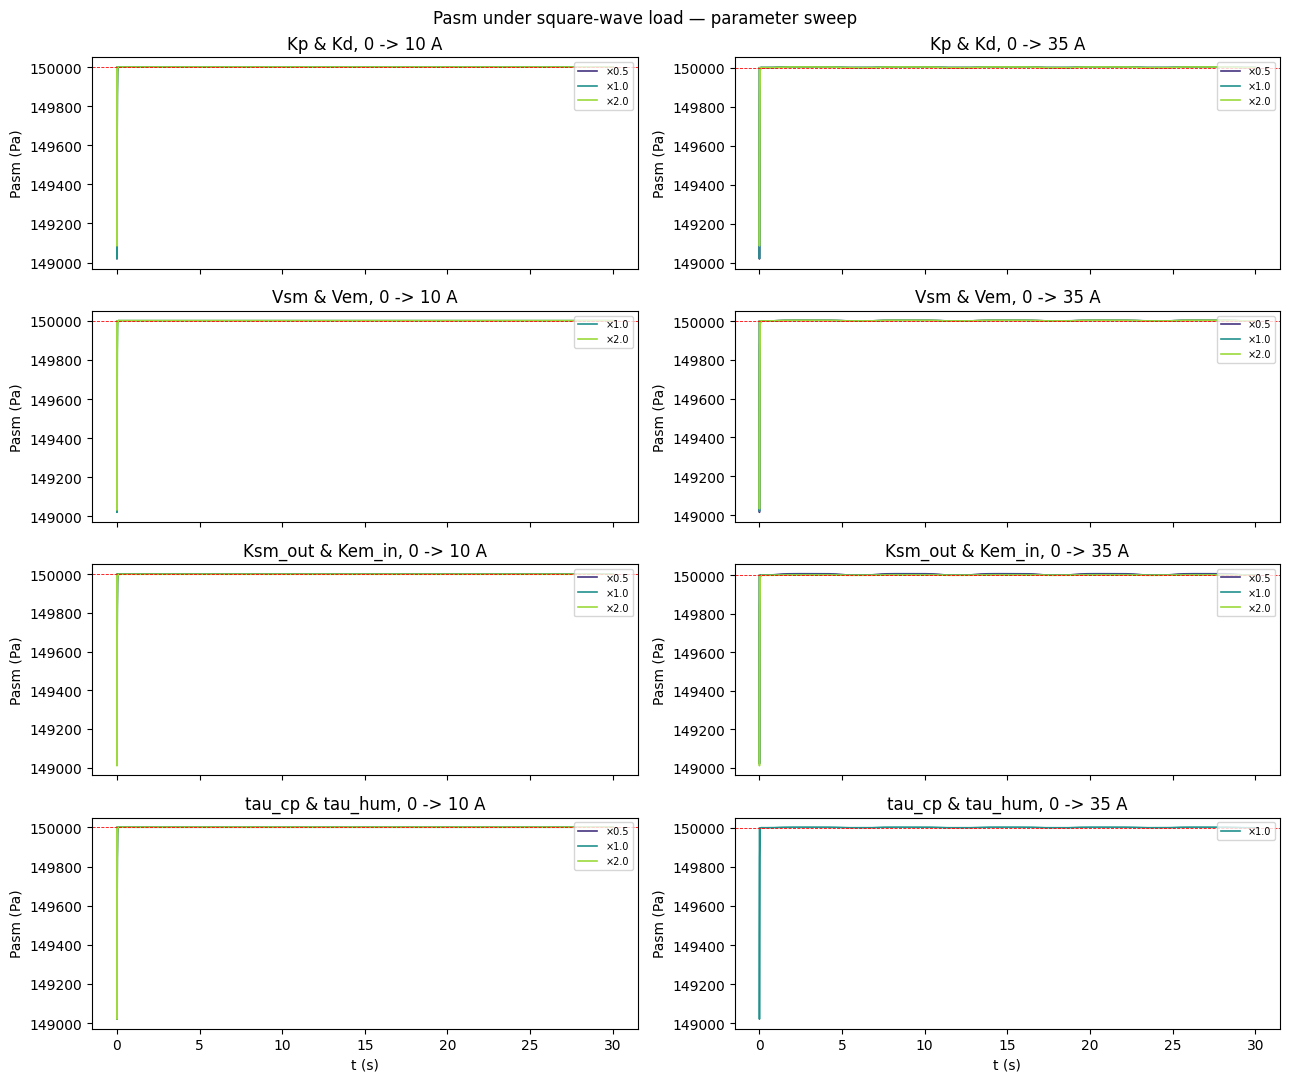

In [11]:
cmap = plt.cm.viridis
colors = [cmap(0.15), cmap(0.5), cmap(0.85)]

fig, ax = plt.subplots(len(SWEEP_GROUPS), len(LOAD_PROFILES),
                       figsize=(13, 11), sharex=True)
for i, gname in enumerate(SWEEP_GROUPS):
    for j, load_name in enumerate(LOAD_PROFILES):
        a = ax[i, j]
        for k, f in enumerate(SWEEP_FACTORS):
            r = sweep_results[(gname, f, load_name)]
            if not r["success"]:
                continue
            a.plot(r["t"], r["Pasm"], color=colors[k], lw=1.2, label=f"×{f:.1f}")
        a.axhline(Pa_des, color="r", ls="--", lw=0.6)
        a.set_title(f"{gname}, {load_name}")
        a.set_ylabel("Pasm (Pa)")
        a.legend(fontsize=7, loc="upper right")
        if i == len(SWEEP_GROUPS) - 1:
            a.set_xlabel("t (s)")
fig.suptitle("Pasm under square-wave load — parameter sweep")
fig.tight_layout()

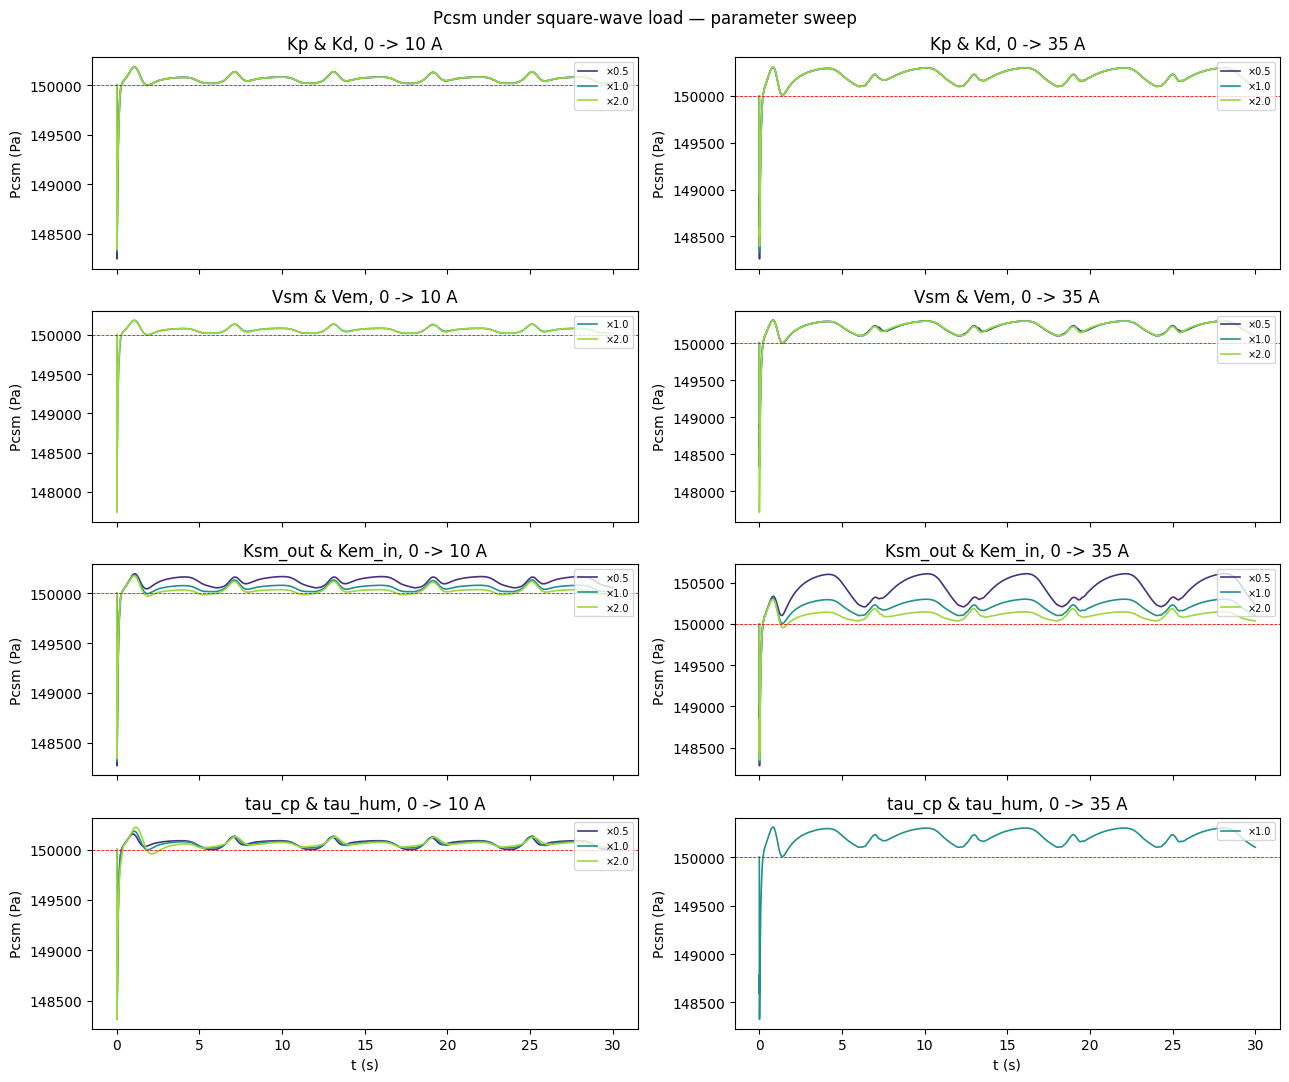

In [12]:
fig, ax = plt.subplots(len(SWEEP_GROUPS), len(LOAD_PROFILES),
                       figsize=(13, 11), sharex=True)
for i, gname in enumerate(SWEEP_GROUPS):
    for j, load_name in enumerate(LOAD_PROFILES):
        a = ax[i, j]
        for k, f in enumerate(SWEEP_FACTORS):
            r = sweep_results[(gname, f, load_name)]
            if not r["success"]:
                continue
            a.plot(r["t"], r["Pcsm"], color=colors[k], lw=1.2, label=f"×{f:.1f}")
        a.axhline(Pc_des, color="r", ls="--", lw=0.6)
        a.set_title(f"{gname}, {load_name}")
        a.set_ylabel("Pcsm (Pa)")
        a.legend(fontsize=7, loc="upper right")
        if i == len(SWEEP_GROUPS) - 1:
            a.set_xlabel("t (s)")
fig.suptitle("Pcsm under square-wave load — parameter sweep")
fig.tight_layout()

In [13]:
rows = []
half_period = PERIOD / 2.0
for gname in SWEEP_GROUPS:
    for f in SWEEP_FACTORS:
        for load_name in LOAD_PROFILES:
            r = sweep_results[(gname, f, load_name)]
            if not r["success"]:
                rows.append({"group": gname, "x": f, "load": load_name, "var": "—",
                             "peak_dev_Pa": np.nan, "settle_1pct_s": np.nan, "rise_10_90_s": np.nan})
                continue
            t_edge = find_rising_edge(r["t"], r["i_fc"], t_min=T_END - 2 * PERIOD)
            for var, P_des in [("Pasm", Pa_des), ("Pcsm", Pc_des)]:
                m = step_metrics(r["t"], r[var], P_des, t_edge, window=half_period)
                rows.append({
                    "group": gname, "x": f, "load": load_name, "var": var,
                    "peak_dev_Pa":   m["peak_dev"],
                    "settle_1pct_s": m["settle_1pct"],
                    "rise_10_90_s":  m["rise_10_90"],
                })
metrics_df = pd.DataFrame(rows)

def _fmt(x):
    if not np.isfinite(x):
        return "    n/a"
    return f"{x:7.3g}"

print(metrics_df.to_string(index=False, formatters={
    "peak_dev_Pa":   _fmt,
    "settle_1pct_s": _fmt,
    "rise_10_90_s":  _fmt,
}))

           group   x      load  var peak_dev_Pa settle_1pct_s rise_10_90_s
         Kp & Kd 0.5 0 -> 10 A Pasm        1.24          1.66            0
         Kp & Kd 0.5 0 -> 10 A Pcsm         128           0.1            0
         Kp & Kd 0.5 0 -> 35 A Pasm        4.35           2.1          0.7
         Kp & Kd 0.5 0 -> 35 A Pcsm         297           2.9          2.1
         Kp & Kd 1.0 0 -> 10 A Pasm        1.24          1.74            0
         Kp & Kd 1.0 0 -> 10 A Pcsm         129           0.2          0.1
         Kp & Kd 1.0 0 -> 35 A Pasm        4.35          2.12        0.629
         Kp & Kd 1.0 0 -> 35 A Pcsm         297          2.92         2.12
         Kp & Kd 2.0 0 -> 10 A Pasm        1.24          1.58            0
         Kp & Kd 2.0 0 -> 10 A Pcsm         129           0.2          0.1
         Kp & Kd 2.0 0 -> 35 A Pasm        4.35             2          0.6
         Kp & Kd 2.0 0 -> 35 A Pcsm         298           2.9            2
       Vsm & Vem 0.5 0 ->

## Interpretation

Reading the panels and the metrics table:

- **`Kp & Kd`** — increasing these gains makes the back-pressure throttle react faster. Expect lower peak deviation and shorter settling at higher factors, until oscillation appears.
- **`Vsm & Vem`** — larger volumes act as gas buffers: peak deviation drops but settling lengthens because more mass has to be moved to re-equalise.
- **`Ksm_out & Kem_in`** — higher orifice coefficients couple the manifold more tightly to the stack, raising the inlet response speed at the cost of larger peak deviation during fast load transients.
- **`tau_cp & tau_hum`** — these are first-order lags on the compressor / humidifier setpoint. They usually dominate the closed-loop response: bigger τ → larger and longer disturbance, especially at the 35 A load where flow demand is highest.

**Comparing 0 → 10 A vs 0 → 35 A**: peak deviation scales roughly with load amplitude (≈ 3.5×). Settling and rise times also grow with load magnitude because the actuators have to chase a larger flow setpoint. If a parameter changes the *ratio* between the two loads (not just the absolute magnitudes), that is the parameter whose nonlinearity dominates at high current.

**Model stability note**: the original target was 0 → 50 A but the dxdt evaluation NaNs above ~35 A (independent of solver choice). That's a model issue rather than a solver issue and is out of scope here — it would need clamping or regularising of the saturation / capillary terms in `inst_values.py`. The 35 A cap still puts us in the same dynamic regime as the existing `square load.ipynb`.

To rerun for a different load amplitude, edit `I_HIGH_HI` / `I_HIGH_LO` in the load-profile cell. To add a parameter, append it to `SWEEP_GROUPS`.